In [6]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
def standard_units(arr):
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

def residuals(t, x, y):
    """Return an array of all the residuals"""
    predictions = fitted_values(t, x, y)
    return t.column(y) - predictions


In [8]:
# Ignore this code; it's graphics for demonstrating the regression model
def draw_and_compare(true_slope, true_int, sample_size):
    x = np.random.normal(50, 5, sample_size)
    xlims = np.array([np.min(x), np.max(x)])
    errors = np.random.normal(0, 6, sample_size)
    y = (true_slope * x + true_int) + errors
    sample = Table().with_columns('x', x, 'y', y)

    sample.scatter('x', 'y')
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title('True Line, and Points Created')

    sample.scatter('x', 'y')
    plt.title('What We Get to See')

    sample.scatter('x', 'y', fit_line=True)
    plt.title('Regression Line: Estimate of True Line')

    sample.scatter('x', 'y', fit_line=True)
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title("Regression Line and True Line")



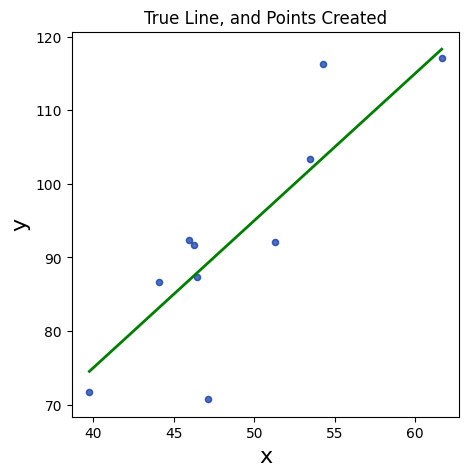

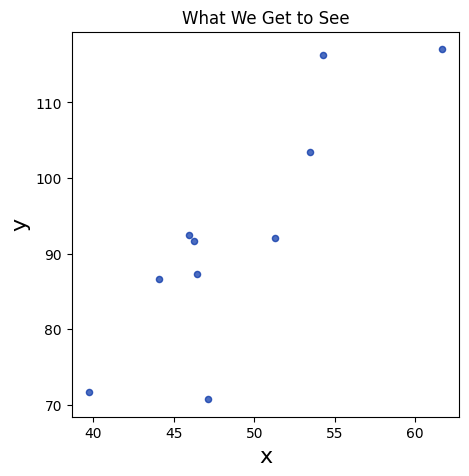

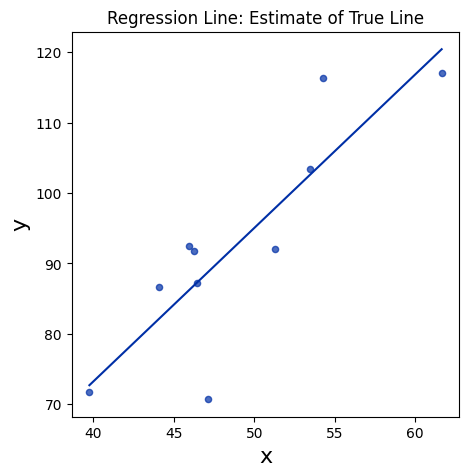

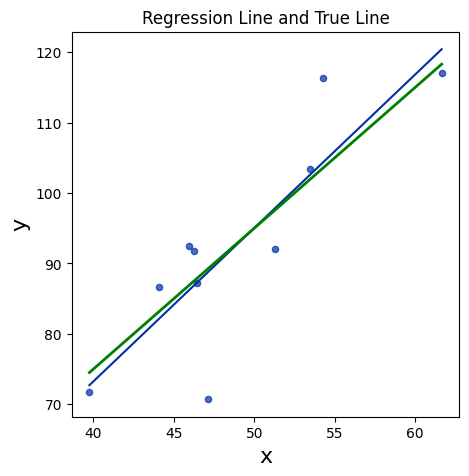

In [9]:
draw_and_compare(2, -5, 10)

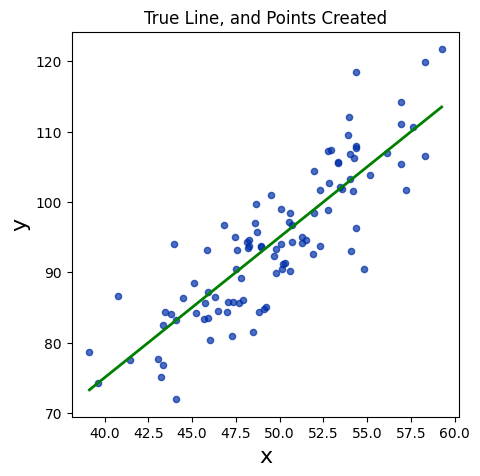

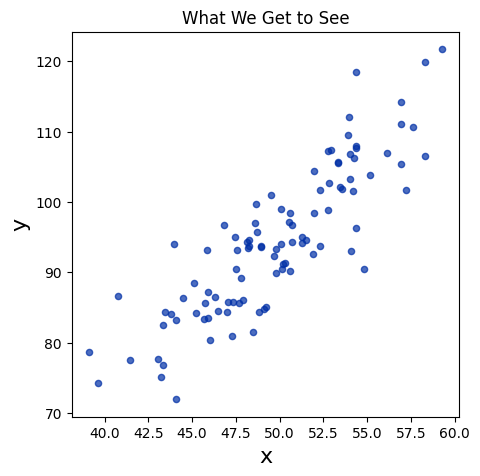

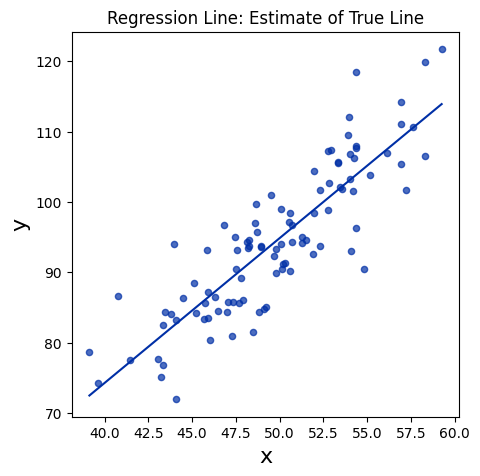

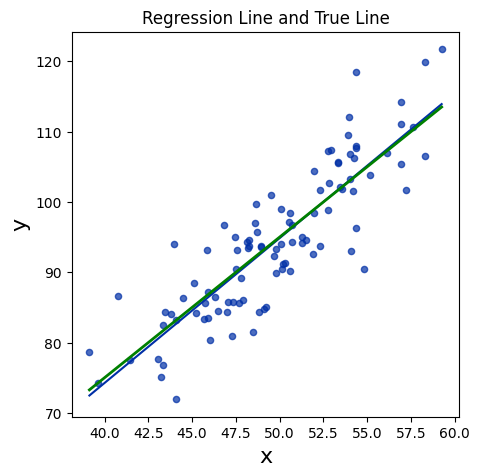

In [11]:
draw_and_compare(2, -5, 100)

In [12]:


births = Table.read_table('baby.csv')
births.show(3)



Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


In [13]:

# Preterm and postterm pregnancy cutoffs, according to the CDC
37 * 7, 42 * 7



(259, 294)

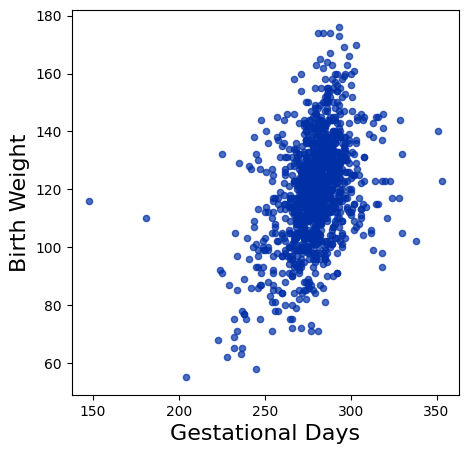

In [14]:
births.scatter('Gestational Days', 'Birth Weight')

In [15]:
births = births.where('Gestational Days', are.between(225, 325))

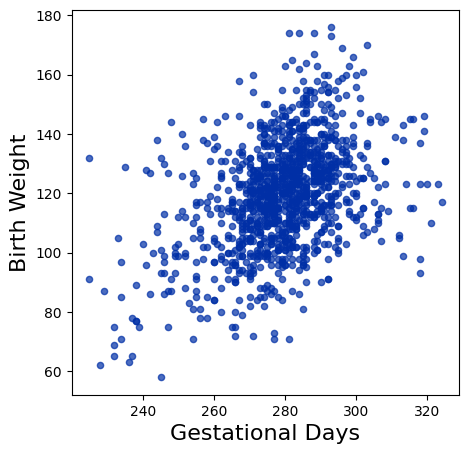

In [16]:
births.scatter('Gestational Days', 'Birth Weight')

In [17]:
correlation(births, 'Gestational Days', 'Birth Weight')

0.42295118452423991

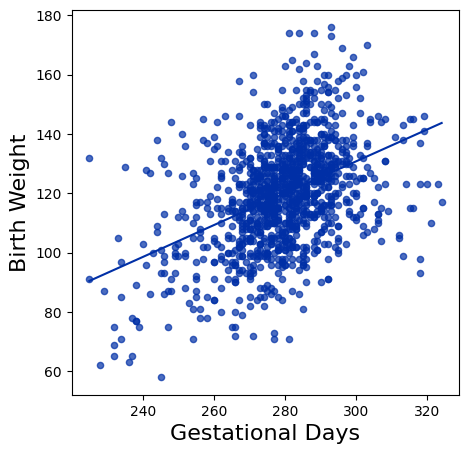

In [18]:
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)

In [19]:


def prediction_at(t, x, y, x_value):
    '''
    t - table
    x - label of x column
    y - label of y column
    x_value - the x value for which we want to predict y
    '''
    return slope(t, x, y) * x_value + intercept(t, x, y)



In [20]:


prediction_at_300 = prediction_at(births, 'Gestational Days', 'Birth Weight', 300)
prediction_at_300



130.80951674248769

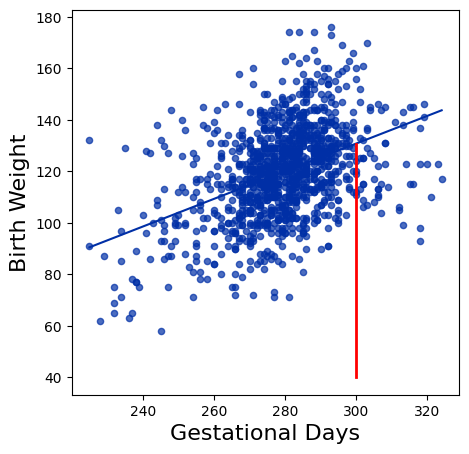

In [22]:


x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plt.plot([x, x], [40, prediction_at_300], color='red', lw=2);



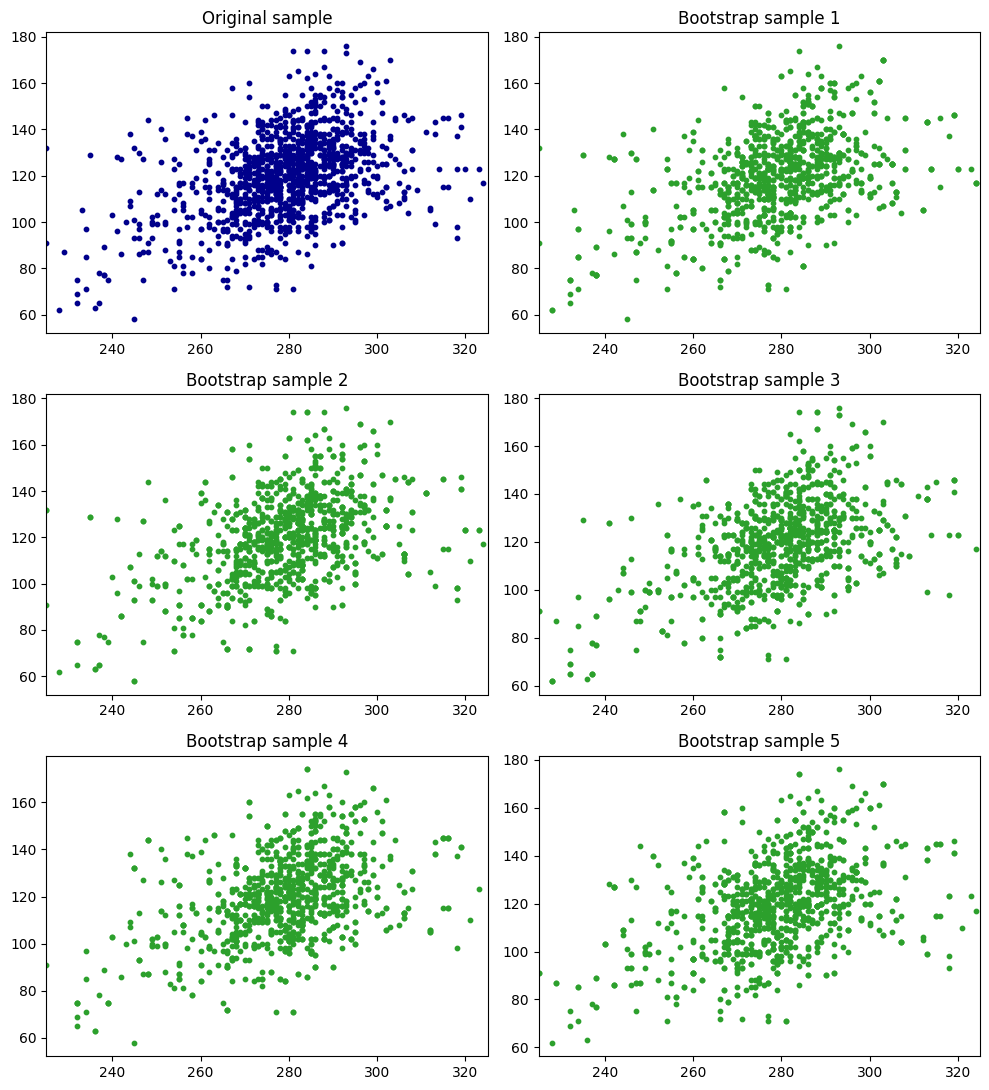

In [24]:
# You don't need to understand the plotting code in this cell,
# but you should understand the figure that comes out.

plt.figure(figsize=(10, 11))
plt.subplot(3, 2, 1)
plt.scatter(births[1], births[0], s=10, color='darkblue')
plt.xlim([225, 325])
plt.title('Original sample')

for i in np.arange(1, 6, 1):
    plt.subplot(3,2,i+1)
    resampled = births.sample()
    plt.scatter(resampled.column('Gestational Days'), resampled.column('Birth Weight'), s=10, color='tab:green')
    plt.xlim([225, 325])
    plt.title('Bootstrap sample '+str(i))
plt.tight_layout()

Predicted y from bootstramp sample was 129.12866904
Predicted y from bootstramp sample was 131.681995867
Predicted y from bootstramp sample was 130.735731704
Predicted y from bootstramp sample was 131.111744125


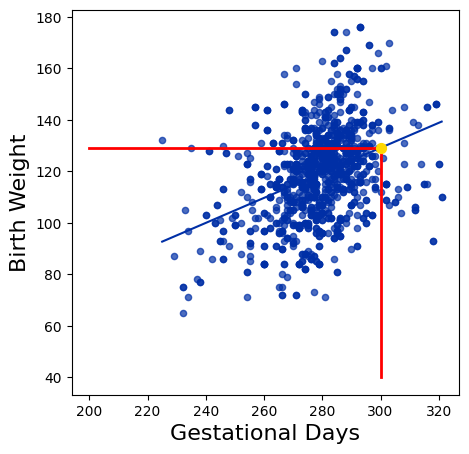

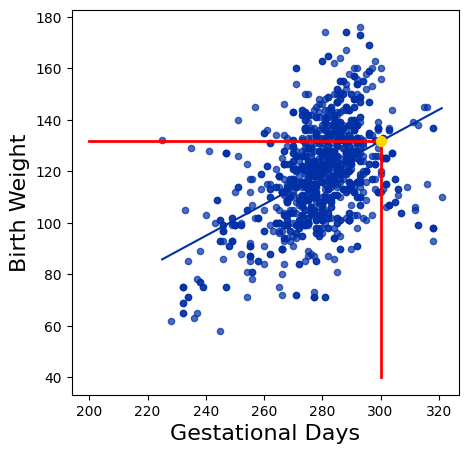

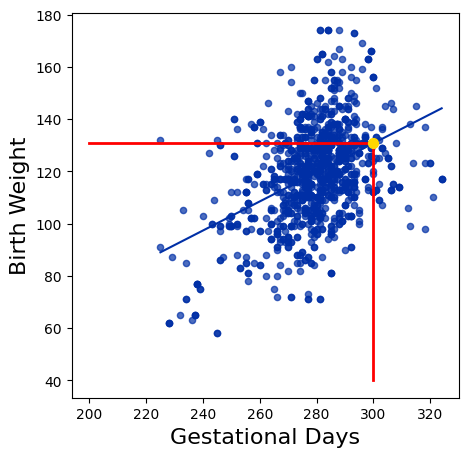

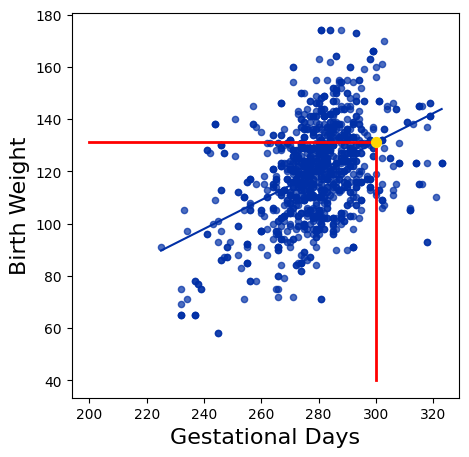

In [25]:
for i in np.arange(4):
    resample = births.sample()
    predicted_y = prediction_at(resample, 'Gestational Days', 'Birth Weight', 300)
    print('Predicted y from bootstramp sample was', predicted_y)
    resample.scatter('Gestational Days', 'Birth Weight', fit_line=True)
    plt.scatter(300, predicted_y, color='gold', s=50, zorder=3);
    plt.plot([x, x], [40, predicted_y], color='red', lw=2);
    plt.plot([200, x], [predicted_y, predicted_y], color='red', lw=2);


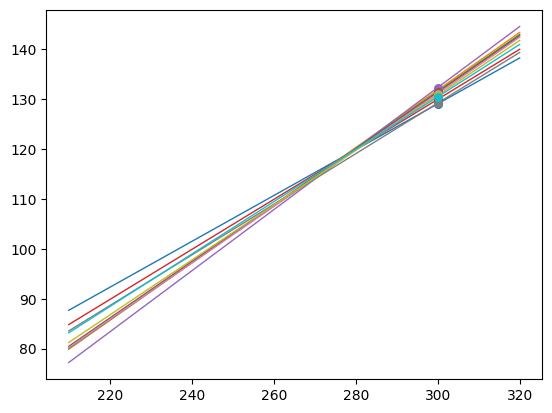

In [26]:
lines = Table(['slope','intercept', 'at 210', 'at 300', 'at 320'])

for i in range(10):
    resample = births.sample()
    a = slope(resample, 'Gestational Days', 'Birth Weight')
    b = intercept(resample, 'Gestational Days', 'Birth Weight')
    lines.append([a, b, a * 210 + b, a * 300 + b, a * 320 + b])

for i in np.arange(lines.num_rows):
    line = lines.row(i)
    plt.plot([210, 320], [line.item('at 210'), line.item('at 320')], lw=1)
    plt.scatter(300, line.item('at 300'), s=30, zorder=3)



In [27]:
np.mean(births.column('Gestational Days')), np.mean(births.column('Birth Weight'))

(279.11015490533561, 119.57401032702238)

In [28]:
lines = Table(['slope','intercept', 'at 291', 'at 300', 'at 309'])

for i in range(10):
    resample = births.sample()
    a = slope(resample, 'Gestational Days', 'Birth Weight')
    b = intercept(resample, 'Gestational Days', 'Birth Weight')
    lines.append([a, b, a * 291 + b, a * 300 + b, a * 309 + b])
lines



slope,intercept,at 291,at 300,at 309
0.636292,-58.3314,126.83,132.556,138.283
0.558141,-36.1521,126.267,131.29,136.314
0.580254,-42.4383,126.416,131.638,136.86
0.507277,-21.9161,125.701,130.267,134.832
0.559891,-37.1411,125.787,130.826,135.865
0.566324,-38.1562,126.644,131.741,136.838
0.547539,-33.1883,126.146,131.074,136.001
0.580173,-41.7781,127.052,132.274,137.495
0.514635,-25.2069,124.552,129.184,133.815
0.644518,-60.6263,126.928,132.729,138.53


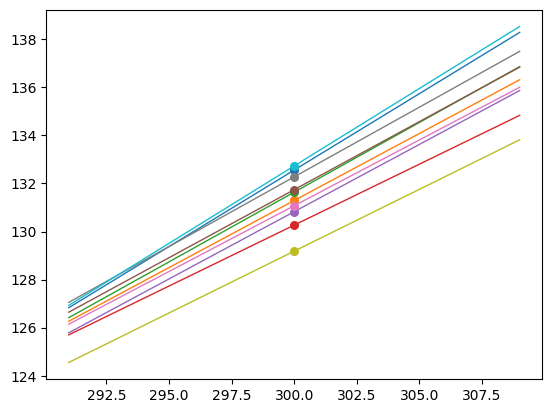

In [30]:
for i in np.arange(lines.num_rows):
    line = lines.row(i)
    plt.plot([291, 309], [line.item('at 291'), line.item('at 309')], lw=1)
    plt.scatter(300, line.item('at 300'), s=30, zorder=3)

In [32]:
def bootstrap_prediction(t, x, y, new_x, repetitions=2500):
    """ 
    Makes a 95% confidence interval for the height of the true line at new_x, 
    using linear regression on the data in t (column names x and y).
    Shows a histogram of the bootstrap samples and shows the interval
    in gold.
    """

    # Bootstrap the scatter, predict, collect
    predictions = make_array()
    for i in np.arange(repetitions):
        resample = t.sample()
        predicted_y = prediction_at(resample, x, y, new_x)
        predictions = np.append(predictions, predicted_y)

    # Find the ends of the approximate 95% prediction interval
    left = percentile(2.5, predictions)
    right = percentile(97.5, predictions)
    round_left = round(left, 3)
    round_right = round(right, 3)

    # Display results
    Table().with_column('Prediction', predictions).hist(bins=20)
    plt.xlabel('predictions at x='+str(new_x))
    plt.plot([left, right], [0, 0], color='yellow', lw=8);
    print('Approximate 95%-confidence interval for height of true line at x =', new_x)
    print(round_left, 'to', round_right, '( width =', round(right - left, 3), ')') 



Approximate 95%-confidence interval for height of true line at x = 300
128.878 to 132.683 ( width = 3.805 )


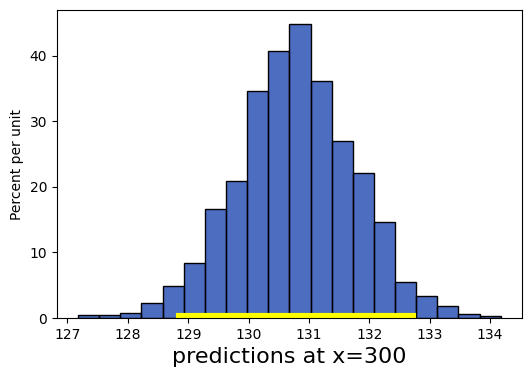

In [33]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 300)

NameError: name 'plots' is not defined

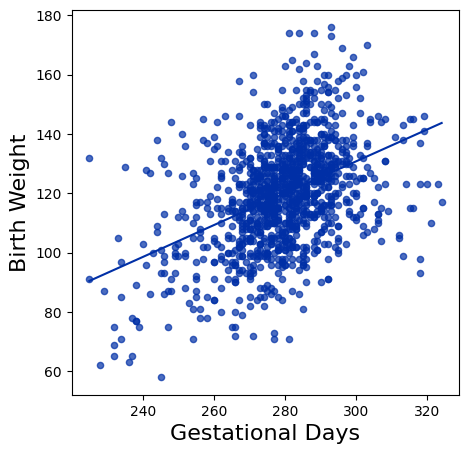

In [34]:
x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plots.plot([x, x], [40, prediction_at_300], color='red', lw=2);

NameError: name 'plots' is not defined

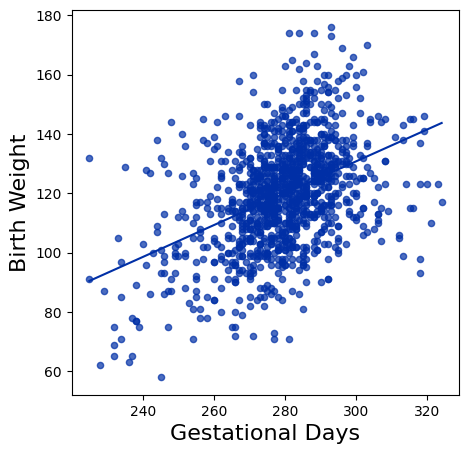

In [35]:
x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plots.plot([x, x], [40, prediction_at_300], color='red', lw=2);

Approximate 95%-confidence interval for height of true line at x = 230
89.045 to 97.049 ( width = 8.004 )


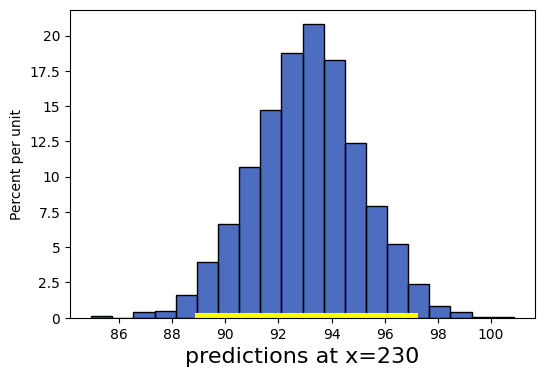

In [36]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 230)

Approximate 95%-confidence interval for height of true line at x = 280
119.057 to 121.038 ( width = 1.98 )


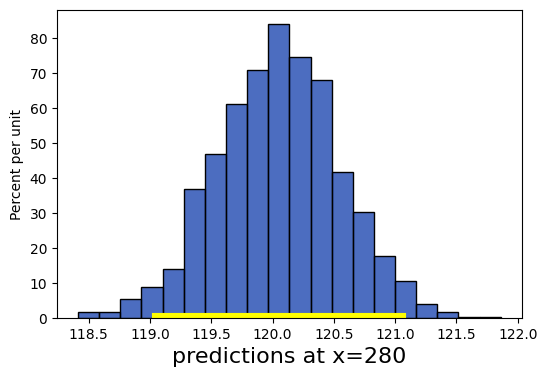

In [37]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 280)

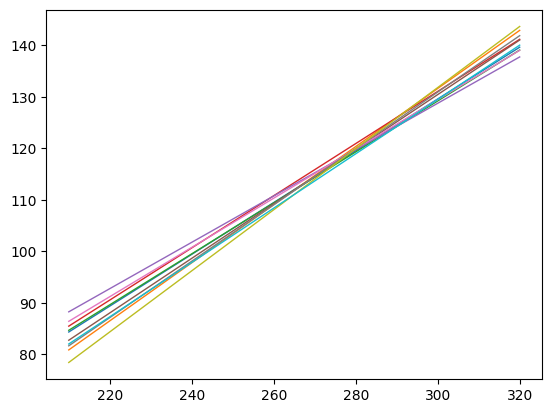

In [39]:
# No need to follow the code in this cell; just understand the graph

lines = Table(['slope','intercept', 'at 210', 'at 300', 'at 320'])

for i in range(10):
    resample = births.sample()
    a = slope(resample, 'Gestational Days', 'Birth Weight')
    b = intercept(resample, 'Gestational Days', 'Birth Weight')
    lines.append([a, b, a * 210 + b, a * 300 + b, a * 320 + b])

for i in np.arange(lines.num_rows):
    line = lines.row(i)
    plt.plot([210, 320], [line.item('at 210'), line.item('at 320')], lw=1)

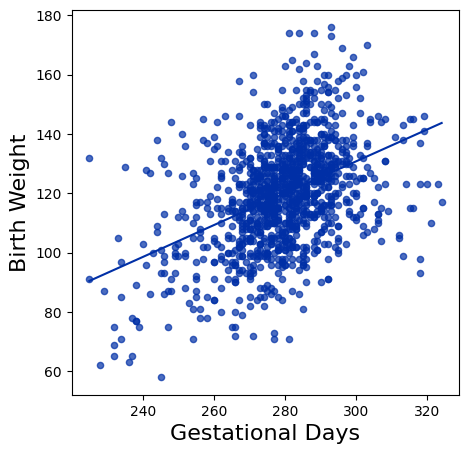

In [40]:
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)

In [41]:
slope(births, 'Gestational Days', 'Birth Weight')

0.53784536766790358

In [42]:
def bootstrap_slope(t, x, y, repetitions=2500):
    """ 
    Makes a 95% confidence interval for the slope of the true line, 
    using linear regression on the data in t (column names x and y).
    Shows a histogram of the bootstrap samples and shows the interval
    in gold.
    """
    
    # Bootstrap the scatter, find the slope, collect
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = t.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)
    
    # Find the endpoints of the 95% confidence interval for the true slope
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)
    round_left = round(left, 3)
    round_right = round(right, 3)
    
    # Slope of the regression line from the original sample
    observed_slope = slope(t, x, y)
    
    # Display results (no need to follow this code)
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', round(observed_slope, 3))
    print('Approximate 95%-confidence interval for the slope of the true line:')
    print(round_left, 'to', round_right)

Slope of regression line: 0.538
Approximate 95%-confidence interval for the slope of the true line:
0.458 to 0.618


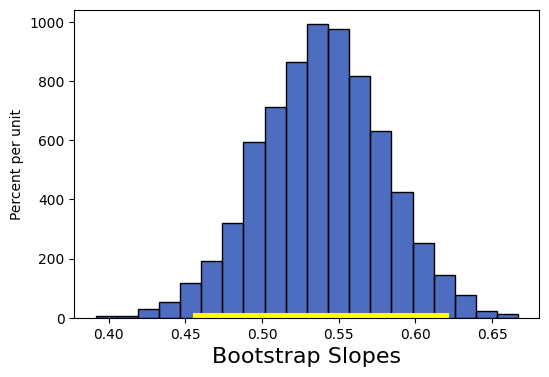

In [43]:
bootstrap_slope(births, 'Gestational Days', 'Birth Weight')

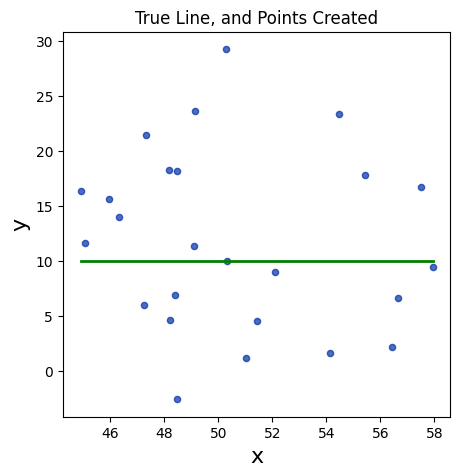

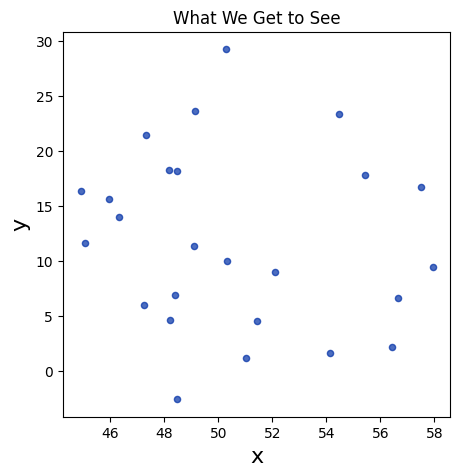

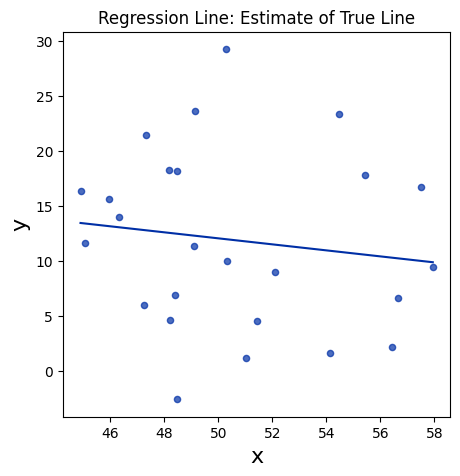

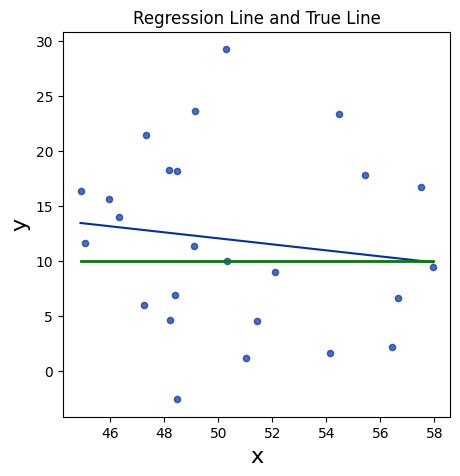

In [44]:
draw_and_compare(0, 10, 25)

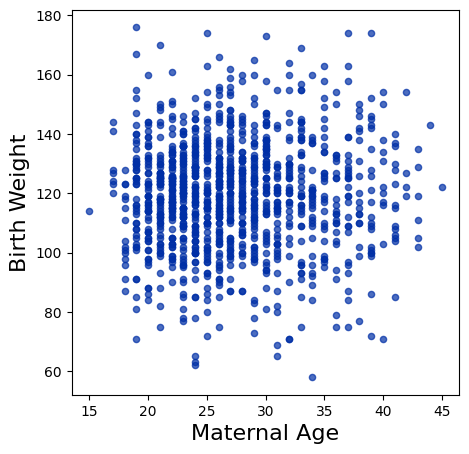

In [45]:
births.scatter('Maternal Age', 'Birth Weight')

In [46]:
slope(births, 'Maternal Age', 'Birth Weight')

0.095142237298344659

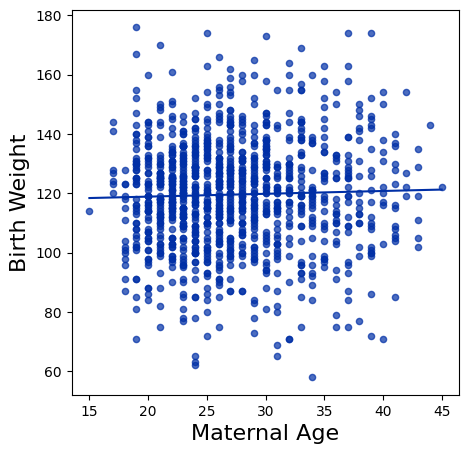

In [47]:
births.scatter('Maternal Age', 'Birth Weight', fit_line=True)

Slope of regression line: 0.095
Approximate 95%-confidence interval for the slope of the true line:
-0.084 to 0.279


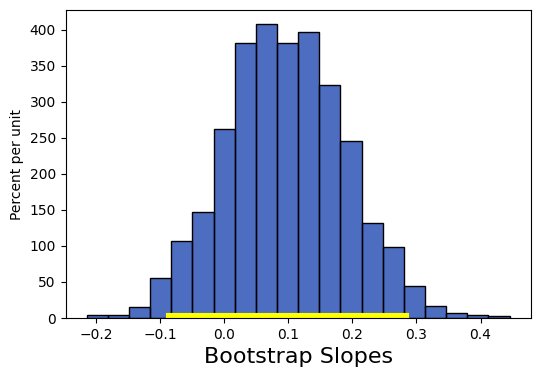

In [48]:
bootstrap_slope(births, 'Maternal Age', 'Birth Weight')